# OCR Model Testing Notebook
This notebook evaluates a trained OCR + text classifier model.

### Imports

In [1]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
from joblib import load
from PIL import Image
import pytesseract
import matplotlib.pyplot as plt
pytesseract.pytesseract.tesseract_cmd = r"C:\Users\ibf\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"
print(pytesseract.get_tesseract_version())


5.5.0.20241111


# Image Path

In [2]:
# IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Error funcional\Cartera\20260512020139_100139.png")
# IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Error aplicativo\20260510012034_100036.png")

IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Error terminal\20260521122524_100177.png")

## Paths

In [ ]:

# Paths

ROOT = Path('..').resolve().parent
DATA_DIR = ROOT / 'Data'
VAL_DIR = ROOT / 'VAL'
MODELS_DIR = ROOT / 'TFM' / 'Models'

MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
CONFIDENCE_THRESHOLD = 0.80

# 🔍 DEBUG PRINTS
print("===== PATH DEBUG =====")
print("Current working dir:", Path.cwd())
print("ROOT:", ROOT)

print("DATA_DIR:", DATA_DIR.resolve())
print("VAL_DIR:", VAL_DIR.resolve())
print("MODELS_DIR:", MODELS_DIR.resolve())

print("\n===== EXISTS CHECK =====")

print("DATA exists:", DATA_DIR.exists())
print("VAL exists:", VAL_DIR.exists())
print("MODELS exists:", MODELS_DIR.exists())

# 🔍 Try to list one image
print("\n===== IMAGE CHECK =====")

print("Image path:", IMAGE_PATH)
print("Exists:", IMAGE_PATH.exists())



===== PATH DEBUG =====
Current working dir: c:\Users\ibf\Desktop\TFM\Nou_projecte\TFM\Inference
ROOT: C:\Users\ibf\Desktop\TFM\Nou_projecte
TEST_DIR: C:\Users\ibf\Desktop\TFM\Nou_projecte\VAL
DATA_DIR: C:\Users\ibf\Desktop\TFM\Nou_projecte\Data
VAL_DIR: C:\Users\ibf\Desktop\TFM\Nou_projecte\VAL
MODELS_DIR: C:\Users\ibf\Desktop\TFM\Nou_projecte\TFM\Models

===== EXISTS CHECK =====
TEST exists: False
DATA exists: True
VAL exists: False
MODELS exists: True

===== IMAGE CHECK =====
Total files found in TEST: 0
Valid images found: 0
 No images found in TEST_DIR
Image path: C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Error terminal\20260521122524_100177.png
Exists: True


## Load Model

In [4]:
# Load model
vectorizer = load(MODELS_DIR / 'ocr_vectorizer.joblib')
clf = load(MODELS_DIR / 'ocr_text_classifier.joblib')
print('Model loaded successfully')

c:\Users\ibf\Desktop\TFM\Nou_projecte\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ibf\Desktop\TFM\Nou_projecte\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model loaded successfully


c:\Users\ibf\Desktop\TFM\Nou_projecte\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# OCR function
def extract_text_from_image(path):
    try:
        img = Image.open(path).convert('RGB')
        return pytesseract.image_to_string(img).strip()
    except Exception as e:
        print(f'Error: {e}')
        return ''

In [6]:
# Prediction function
def predict(image_path, threshold=0.8):
    text = extract_text_from_image(image_path)
    if text == '':
        return 'Indeterminado', 0.0
    X = vectorizer.transform([text])
    probs = clf.predict_proba(X)[0]
    idx = probs.argmax()
    label = clf.classes_[idx]
    conf = probs[idx]
    if conf < threshold:
        label = 'Indeterminado'
    return label, conf

### Execute

In [7]:
# Run on ONE image
image_path = IMAGE_PATH

label, conf = predict(str(image_path))

df = pd.DataFrame([{
    'path': str(image_path),
    'prediction': label,
    'confidence': conf
}])

df

,path,prediction,confidence
0,C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Err...,Error terminal,0.879402


## Show results

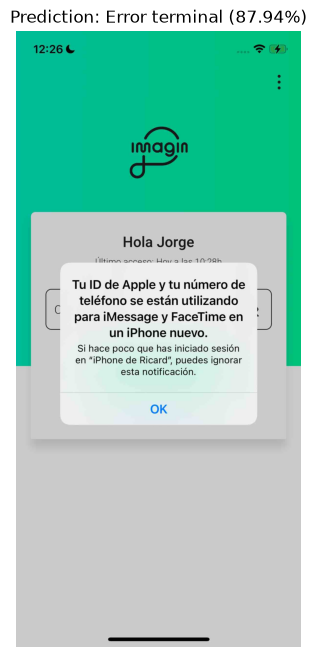

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path).convert('RGB')

plt.figure(figsize=(5, 8))
plt.imshow(image)
plt.title(f"Prediction: {label} ({conf:.2%})")
plt.axis('off')
plt.show()
